In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal, gaussian_kde
from scipy.optimize import curve_fit
from scikit_posthocs import posthoc_dunn

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold, cross_val_score, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score)

def rmse(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))

def washburn_radius(L, gamma, t, phi, eta):
    L = np.asarray(L, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    t = np.asarray(t, dtype=float)
    phi = np.asarray(phi, dtype=float)
    eta = np.asarray(eta, dtype=float)
    denom = gamma * t * np.cos(phi)
    return (2 * eta * L**2) / denom

def washburn_length(r, gamma, t, phi, eta):
    r = np.asarray(r, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    t = np.asarray(t, dtype=float)
    phi = np.asarray(phi, dtype=float)
    eta = np.asarray(eta, dtype=float)
    inside = (gamma * r * t * np.cos(phi)) / (2 * eta)
    return np.sqrt(inside)

def evaluate_regression(y_true, y_pred):
    return {"MAE": mean_absolute_error(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "R2": r2_score(y_true, y_pred)}

def inspect_dataframe(name, df):
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nHead:")
    print(df.head())
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nSummary statistics:")
    print(df.describe(include="all"))


dunking-data.csv
Shape: (3000, 6)

Columns: ['gamma', 'phi', 'eta', 'L', 't', 'biscuit']

Head:
      gamma       phi       eta         L          t    biscuit
0  0.073897  1.333006  0.000999  0.011196  19.362214  Digestive
1  0.080946  1.476758  0.001012  0.005894  11.852589  Digestive
2  0.087408  1.477141  0.000984  0.009249  24.793669  Digestive
3  0.070793  1.502001  0.001002  0.003774  16.292780     Hobnob
4  0.058917  1.548274  0.001004  0.002291  13.662271     Hobnob

Missing values:
gamma      0
phi        0
eta        0
L          0
t          0
biscuit    0
dtype: int64

Duplicate rows: 0

Summary statistics:
              gamma          phi          eta            L            t  \
count   3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
unique          NaN          NaN          NaN          NaN          NaN   
top             NaN          NaN          NaN          NaN          NaN   
freq            NaN          NaN          NaN          NaN          NaN

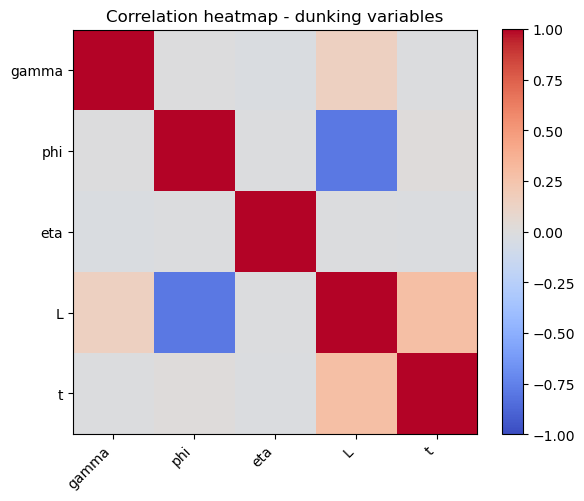

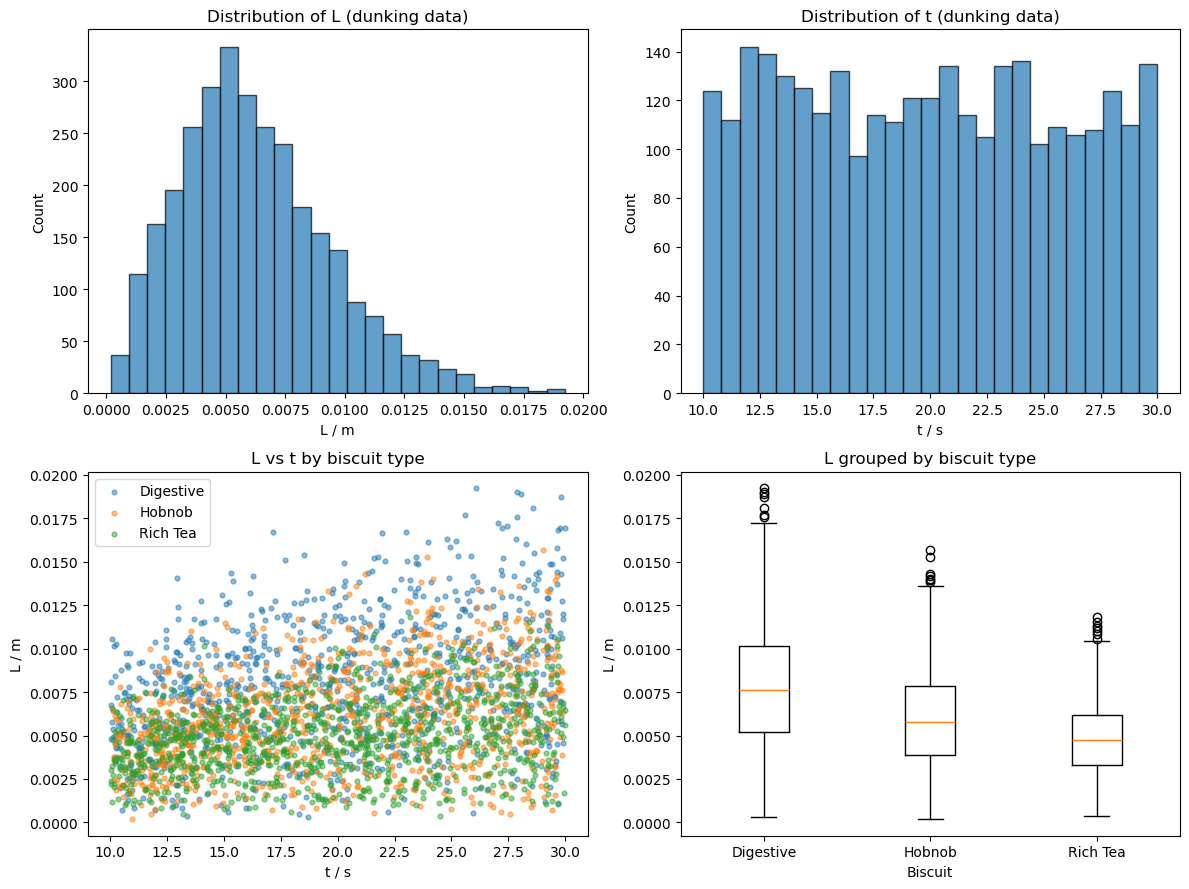

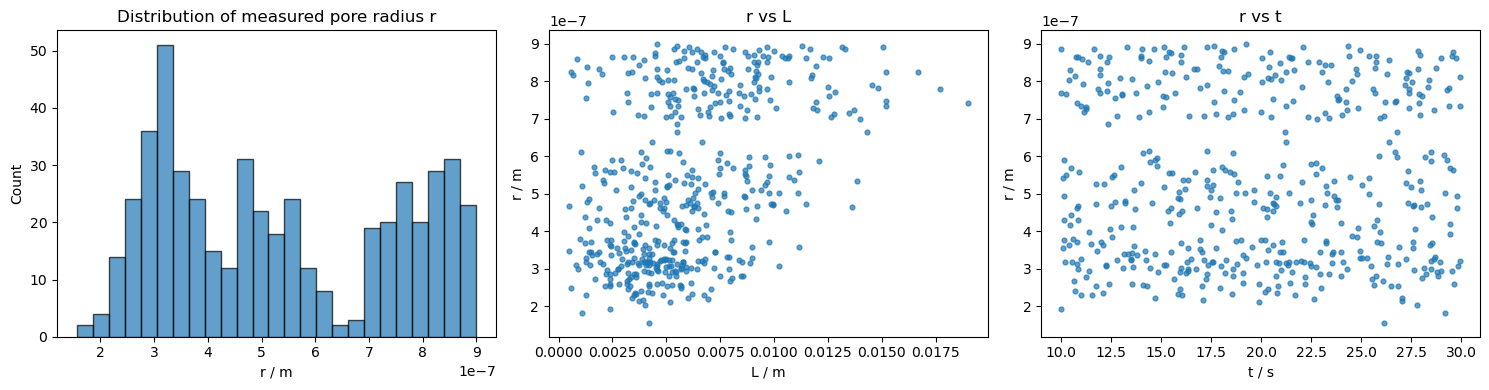

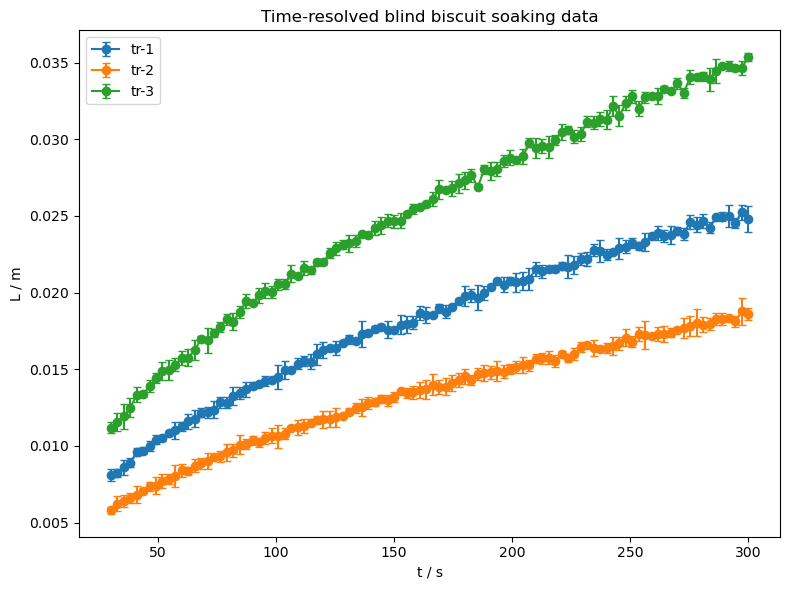

In [2]:
dunk = pd.read_csv("dunking-data.csv")
micro = pd.read_csv("microscopy-data.csv")
tr1 = pd.read_csv("tr-1.csv")
tr2 = pd.read_csv("tr-2.csv")
tr3 = pd.read_csv("tr-3.csv")

blind_samples = {"tr-1": tr1.copy(), "tr-2": tr2.copy(), "tr-3": tr3.copy()}

inspect_dataframe("dunking-data.csv", dunk)
inspect_dataframe("microscopy-data.csv", micro)
inspect_dataframe("tr-1.csv", tr1)
inspect_dataframe("tr-2.csv", tr2)
inspect_dataframe("tr-3.csv", tr3)

print("\nBiscuit class counts:")
print(dunk["biscuit"].value_counts())

dunk["abs_cos_phi"] = np.abs(np.cos(dunk["phi"]))
micro["abs_cos_phi"] = np.abs(np.cos(micro["phi"]))

print("\nPotentially inaccurate Washburn inversions")
print("dunk rows with |cos(phi)| < 0.001:", int((dunk["abs_cos_phi"] < 0.001).sum()))
print("micro rows with |cos(phi)| < 0.001:", int((micro["abs_cos_phi"] < 0.001).sum()))

corr_cols = ["gamma", "phi", "eta", "L", "t"] #correlation heatmap
corr = dunk[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
ax.set_title("Correlation heatmap - dunking variables")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 9)) #distribution and scatter plots 

axes[0, 0].hist(dunk["L"], bins=25, edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Distribution of L (dunking data)")
axes[0, 0].set_xlabel("L / m")
axes[0, 0].set_ylabel("Count")

axes[0, 1].hist(dunk["t"], bins=25, edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Distribution of t (dunking data)")
axes[0, 1].set_xlabel("t / s")
axes[0, 1].set_ylabel("Count")

for biscuit in dunk["biscuit"].unique():
    sub = dunk[dunk["biscuit"] == biscuit]
    axes[1, 0].scatter(sub["t"], sub["L"], alpha=0.5, s=12, label=biscuit)
axes[1, 0].set_title("L vs t by biscuit type")
axes[1, 0].set_xlabel("t / s")
axes[1, 0].set_ylabel("L / m")
axes[1, 0].legend()

biscuit_order = sorted(dunk["biscuit"].unique())
box_data = [dunk.loc[dunk["biscuit"] == b, "L"] for b in biscuit_order]
axes[1, 1].boxplot(box_data, tick_labels=biscuit_order)
axes[1, 1].set_title("L grouped by biscuit type")
axes[1, 1].set_xlabel("Biscuit")
axes[1, 1].set_ylabel("L / m")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4)) #micro scatter plots
axes[0].hist(micro["r"], bins=25, edgecolor="black", alpha=0.7)
axes[0].set_title("Distribution of measured pore radius r")
axes[0].set_xlabel("r / m")
axes[0].set_ylabel("Count")
axes[1].scatter(micro["L"], micro["r"], alpha=0.7, s=12)
axes[1].set_title("r vs L")
axes[1].set_xlabel("L / m")
axes[1].set_ylabel("r / m")
axes[2].scatter(micro["t"], micro["r"], alpha=0.7, s=12)
axes[2].set_title("r vs t")
axes[2].set_xlabel("t / s")
axes[2].set_ylabel("r / m")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6)) #blind time data
for name, df in blind_samples.items():
    ax.errorbar(df["t"], df["L"], yerr=df["dL"], fmt="o-", capsize=3, label=name)
ax.set_title("Time-resolved blind biscuit soaking data")
ax.set_xlabel("t / s")
ax.set_ylabel("L / m")
ax.legend()
plt.tight_layout()
plt.show()

Dunking data with inferred effective pore radius:
      gamma       phi       eta         L          t    biscuit         r_eff
0  0.073897  1.333006  0.000999  0.011196  19.362214  Digestive  7.429094e-07
1  0.080946  1.476758  0.001012  0.005894  11.852589  Digestive  7.803690e-07
2  0.087408  1.477141  0.000984  0.009249  24.793669  Digestive  8.302559e-07
3  0.070793  1.502001  0.001002  0.003774  16.292780     Hobnob  3.598074e-07
4  0.058917  1.548274  0.001004  0.002291  13.662271     Hobnob  5.814437e-07

r_eff outliers outside IQR bounds: 0

Summary of inferred effective pore radius by biscuit:
           count          mean        median           std           min  \
biscuit                                                                    
Digestive   1000  8.021261e-07  8.049362e-07  5.964216e-08  6.766981e-07   
Hobnob      1000  5.003074e-07  5.008655e-07  8.079370e-08  2.337422e-07   
Rich Tea    1000  3.020585e-07  3.038294e-07  5.068362e-08  1.328849e-07   

        

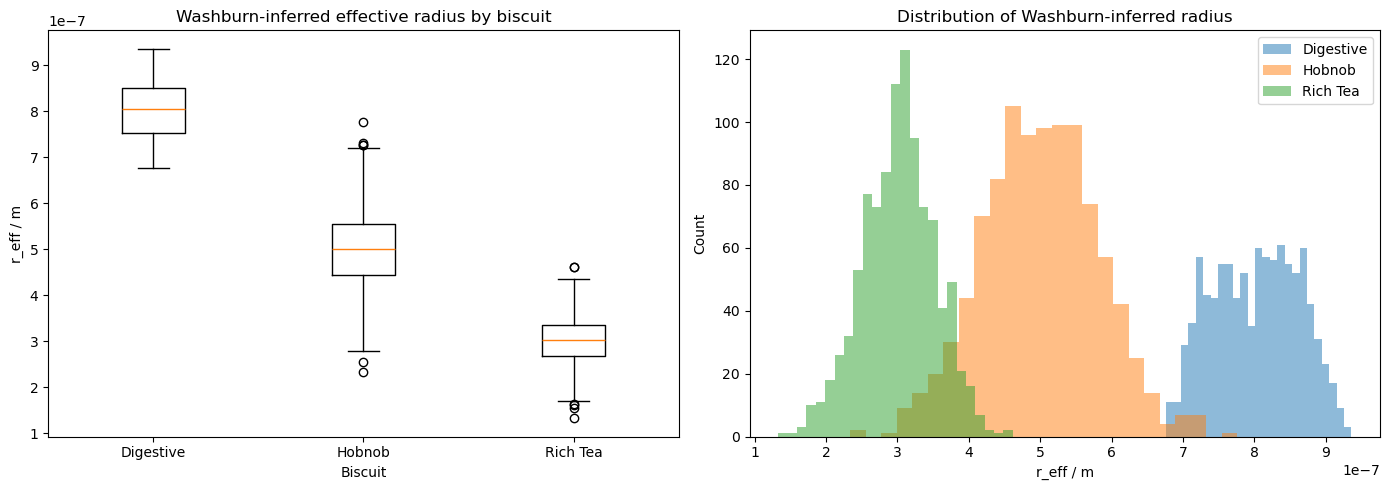


Microscopy comparison metrics
Radius comparison: {'MAE': 8.235688805480634e-09, 'RMSE': 1.094522652440573e-08, 'R2': 0.9974355340071894}
Length prediction using microscopy radius: {'MAE': 4.636394889666097e-05, 'RMSE': 6.434742175559671e-05, 'R2': 0.9995897989551944}


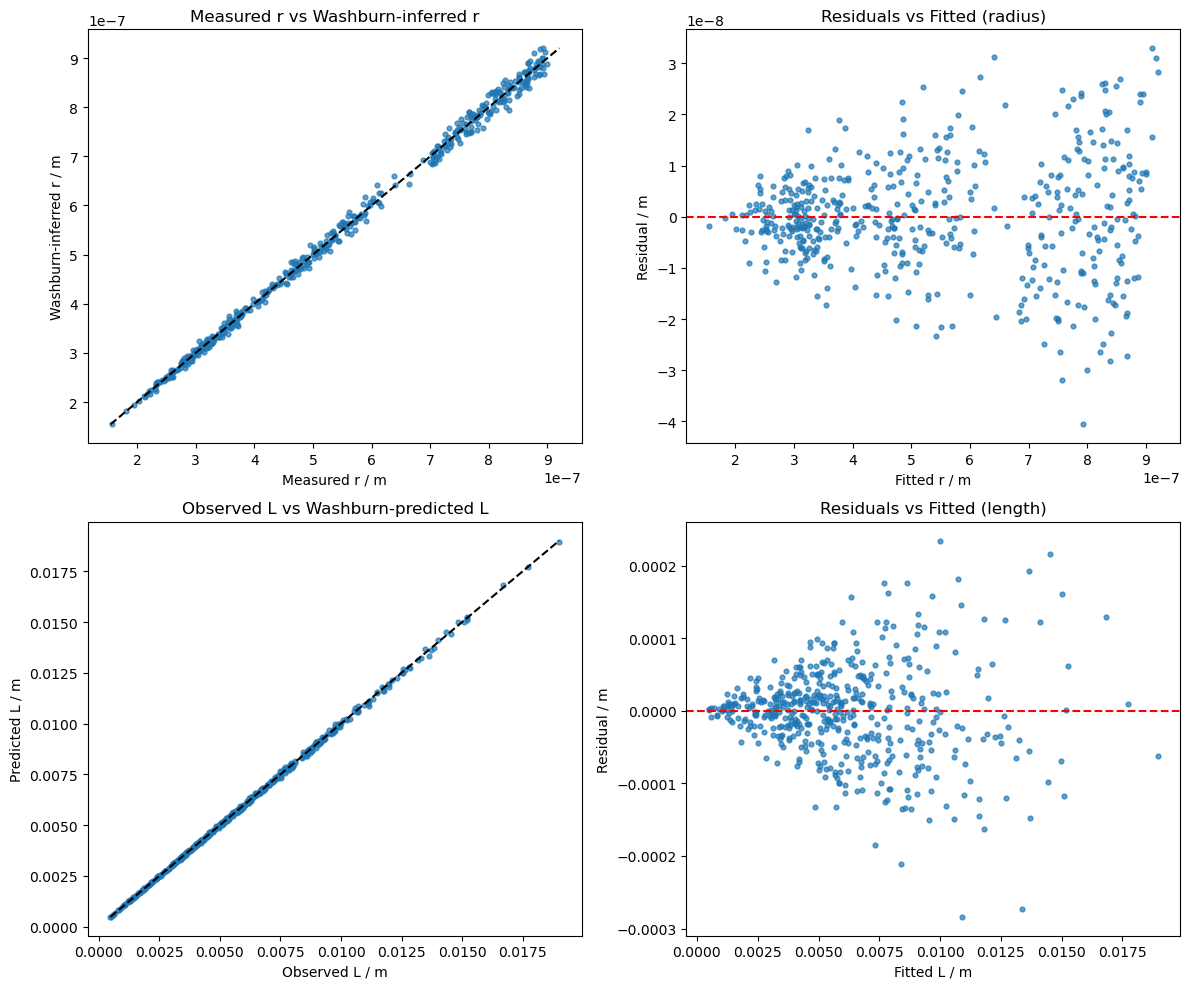

tr-1: r_fit = 5.1862e-07 +/- 1.0284e-09 m
tr-2: r_fit = 2.8026e-07 +/- 9.6853e-10 m
tr-3: r_fit = 1.0048e-06 +/- 4.5343e-10 m

Blind sample radius summary:
  sample    mean_r_eff  median_r_eff     std_r_eff         r_fit     r_fit_err
2   tr-3  1.003606e-06  1.002283e-06  1.938550e-08  1.004803e-06  4.534299e-10
0   tr-1  5.190558e-07  5.200957e-07  1.042269e-08  5.186196e-07  1.028353e-09
1   tr-2  2.794291e-07  2.794716e-07  5.364656e-09  2.802635e-07  9.685285e-10


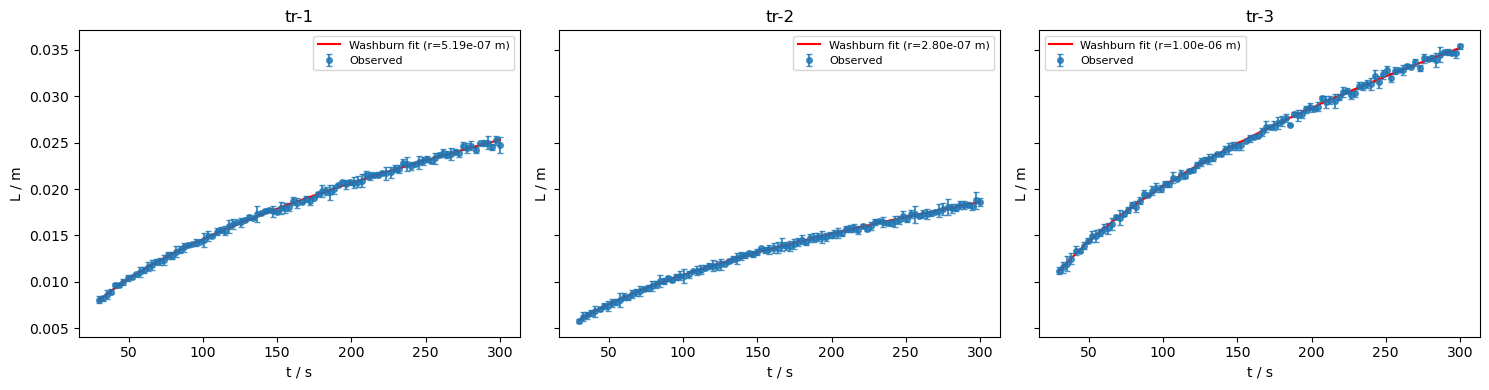

In [3]:
dunk_phys = dunk.copy()
micro_phys = micro.copy()

dunk_phys["r_eff"] = washburn_radius(L=dunk_phys["L"], gamma=dunk_phys["gamma"], t=dunk_phys["t"], phi=dunk_phys["phi"], eta=dunk_phys["eta"]) #effective pore radius from Washburn equation

print("Dunking data with inferred effective pore radius:")
print(dunk_phys[["gamma", "phi", "eta", "L", "t", "biscuit", "r_eff"]].head())

q1 = dunk_phys["r_eff"].quantile(0.25) #find outliers with interquartile range
q3 = dunk_phys["r_eff"].quantile(0.75)
iqr = q3 - q1
n_outliers = int(((dunk_phys["r_eff"] < q1 - 1.5*iqr) | (dunk_phys["r_eff"] > q3 + 1.5*iqr)).sum()) #count outliers
print(f"\nr_eff outliers outside IQR bounds: {n_outliers}")

radius_summary = (dunk_phys.groupby("biscuit")["r_eff"].agg(["count", "mean", "median", "std", "min", "max"]).sort_values("mean", ascending=False)) #summarise each biscuit type
print("\nSummary of inferred effective pore radius by biscuit:")
print(radius_summary)

biscuit_order = sorted(dunk_phys["biscuit"].unique()) #kruskal-wallis test
groups = [dunk_phys.loc[dunk_phys["biscuit"] == b, "r_eff"].dropna().values for b in biscuit_order] #seperate r_eff into one group / bisucit 
kw_stat, kw_p = kruskal(*groups) #tests if r_eff distributions differ significantly
print(f"\nKruskal-Wallis test: H = {kw_stat:.4f}, p = {kw_p:.4e}")

dunn_data = dunk_phys.dropna(subset=["r_eff"]) #post hoc dunns test
dunn_result = posthoc_dunn(dunn_data, val_col="r_eff", group_col="biscuit", p_adjust="bonferroni") #sees which biscuit pairs differ significantly
print("\nDunn's post-hoc test:")
print(dunn_result)

fig, axes = plt.subplots(1, 2, figsize=(14, 5)) #effective pore radius by biscuit type

box_data = [dunk_phys.loc[dunk_phys["biscuit"] == b, "r_eff"].dropna() for b in biscuit_order]
axes[0].boxplot(box_data, tick_labels=biscuit_order)
axes[0].set_title("Washburn-inferred effective radius by biscuit")
axes[0].set_xlabel("Biscuit")
axes[0].set_ylabel("r_eff / m")
axes[0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

for biscuit in biscuit_order:
    sub = dunk_phys[dunk_phys["biscuit"] == biscuit]
    axes[1].hist(sub["r_eff"].dropna(), bins=25, alpha=0.5, label=biscuit)
axes[1].set_title("Distribution of Washburn-inferred radius")
axes[1].set_xlabel("r_eff / m")
axes[1].set_ylabel("Count")
axes[1].ticklabel_format(axis="x", style="sci", scilimits=(0, 0))
axes[1].legend()
plt.tight_layout()
plt.show()

micro_phys["r_washburn"] = washburn_radius(L=micro_phys["L"], gamma=micro_phys["gamma"], t=micro_phys["t"], phi=micro_phys["phi"], eta=micro_phys["eta"]) #compare micro r against measured pore r
micro_phys["L_washburn_from_r"] = washburn_length(r=micro_phys["r"], gamma=micro_phys["gamma"], t=micro_phys["t"], phi=micro_phys["phi"], eta=micro_phys["eta"]) #predict L from micro r
micro_phys["r_residual"] = micro_phys["r_washburn"] - micro_phys["r"]
micro_phys["L_residual"] = micro_phys["L_washburn_from_r"] - micro_phys["L"]

mask_r = micro_phys["r"].notna() & micro_phys["r_washburn"].notna()
mask_L = micro_phys["L"].notna() & micro_phys["L_washburn_from_r"].notna()

r_metrics = evaluate_regression(micro_phys.loc[mask_r, "r"], micro_phys.loc[mask_r, "r_washburn"])
L_metrics = evaluate_regression(micro_phys.loc[mask_L, "L"], micro_phys.loc[mask_L, "L_washburn_from_r"])

print("\nMicroscopy comparison metrics")
print("Radius comparison:", r_metrics)
print("Length prediction using microscopy radius:", L_metrics)

fig, axes = plt.subplots(2, 2, figsize=(12, 10)) #micro plots with residuals

r_min = np.nanmin([micro_phys["r"].min(), micro_phys["r_washburn"].min()])
r_max = np.nanmax([micro_phys["r"].max(), micro_phys["r_washburn"].max()])
axes[0, 0].scatter(micro_phys["r"], micro_phys["r_washburn"], alpha=0.7, s=12)
axes[0, 0].plot([r_min, r_max], [r_min, r_max], "k--")
axes[0, 0].set_title("Measured r vs Washburn-inferred r")
axes[0, 0].set_xlabel("Measured r / m")
axes[0, 0].set_ylabel("Washburn-inferred r / m")
axes[0, 0].ticklabel_format(axis="both", style="sci", scilimits=(0, 0))

axes[0, 1].scatter(micro_phys["r_washburn"], micro_phys["r_residual"], alpha=0.7, s=12)
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("Residuals vs Fitted (radius)")
axes[0, 1].set_xlabel("Fitted r / m")
axes[0, 1].set_ylabel("Residual / m")
axes[0, 1].ticklabel_format(axis="both", style="sci", scilimits=(0, 0))

L_min = np.nanmin([micro_phys["L"].min(), micro_phys["L_washburn_from_r"].min()])
L_max = np.nanmax([micro_phys["L"].max(), micro_phys["L_washburn_from_r"].max()])
axes[1, 0].scatter(micro_phys["L"], micro_phys["L_washburn_from_r"], alpha=0.7, s=12)
axes[1, 0].plot([L_min, L_max], [L_min, L_max], "k--")
axes[1, 0].set_title("Observed L vs Washburn-predicted L")
axes[1, 0].set_xlabel("Observed L / m")
axes[1, 0].set_ylabel("Predicted L / m")

axes[1, 1].scatter(micro_phys["L_washburn_from_r"], micro_phys["L_residual"], alpha=0.7, s=12)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("Residuals vs Fitted (length)")
axes[1, 1].set_xlabel("Fitted L / m")
axes[1, 1].set_ylabel("Residual / m")

plt.tight_layout()
plt.show()

gamma_tr = 6.78e-2 #effective radius and washburn fit
phi_tr = 1.45
eta_tr = 9.93e-4

def washburn_curve(t, r):
    return np.sqrt((gamma_tr * r * t * np.cos(phi_tr)) / (2 * eta_tr))

blind_phys = {}
blind_fit_results = {}

for name, df in blind_samples.items():
    df = df.copy()
    df["gamma"] = gamma_tr
    df["phi"] = phi_tr
    df["eta"] = eta_tr

    df["r_eff"] = washburn_radius(L=df["L"].values, gamma=df["gamma"].values, t=df["t"].values, phi=df["phi"].values, eta=df["eta"].values) 
    with np.errstate(divide="ignore", invalid="ignore"):
        df["dr_eff"] = np.abs((4 * eta_tr * df["L"].values) / (gamma_tr * df["t"].values * np.cos(phi_tr))) * df["dL"].values

    blind_phys[name] = df

    popt, pcov = curve_fit(washburn_curve, df["t"].values, df["L"].values, p0=[1e-6], sigma=df["dL"].values, absolute_sigma=True) #fit washburn curve to blind data
    r_fit = popt[0]
    r_fit_err = np.sqrt(pcov[0, 0])
    blind_fit_results[name] = {"r_fit": r_fit, "r_fit_err": r_fit_err}
    print(f"{name}: r_fit = {r_fit:.4e} +/- {r_fit_err:.4e} m")

blind_radius_summary = []

for name, df in blind_phys.items():
    blind_radius_summary.append({"sample": name, "mean_r_eff": df["r_eff"].mean(), "median_r_eff": df["r_eff"].median(), "std_r_eff": df["r_eff"].std(), "r_fit": blind_fit_results[name]["r_fit"], "r_fit_err": blind_fit_results[name]["r_fit_err"],})

blind_radius_summary = pd.DataFrame(blind_radius_summary).sort_values("r_fit", ascending=False)
print("\nBlind sample radius summary:")
print(blind_radius_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, df) in zip(axes, blind_phys.items()):
    ax.errorbar(df["t"], df["L"], yerr=df["dL"], fmt="o", capsize=2, ms=4, alpha=0.8, label="Observed")
    t_smooth = np.linspace(df["t"].min(), df["t"].max(), 200)
    r_fit = blind_fit_results[name]["r_fit"]
    ax.plot(t_smooth, washburn_curve(t_smooth, r_fit), "r-",
            label=f"Washburn fit (r={r_fit:.2e} m)")
    ax.set_title(name)
    ax.set_xlabel("t / s")
    ax.set_ylabel("L / m")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()